In [1]:
from MobilityHubDataObjects import *
import geopandas as gpd
import folium
import datetime as dt

In [2]:
CONFIG_MAP_AREA_PATH = "map_area_path"
CONFIG_MAP_AREA_PROJECTED_CRS = "map_area_projected_crs"
CONFIG_GTFS_TRANSITLAND_URL = "gtfs_url"
CONFIG_GTFS_TRANSITLAND_KEY_PATH = "gtfs_key_path"
CONFIG_GTFS_CACHE_FOLDER = "gtfs_cache_folder"
CONFIG_GTFS_OVERRIDE_SHEET = "gtfs_override_sheet"
CONFIG_FTA_FACILITY_INVENTORY_PATH = "fta_facility_inventory_path"
CONFIG_TIGER_STATES_PATH = "tiger_states_path"
CONFIG_CITYBIKES_URL = "citybikes_url"
CONFIG_AFDC_API_KEY = "afdc_api_key"
CONFIG_AFDC_URL = "afdc_url"
CONFIG_OSM_CACHE_FOLDER = "osm_cache_folder"
CONFIG_EPA_EJSCREEN_PATH = "epa_ejscreen_path"
CONFIG_SMART_LOCATION_PATH = "smart_location_path"

GEODESIC_CRS = 4326

WAYNE_COUNTY_PATH = "./rawData/waynecounty.geojson"
WAYNE_COUNTY_GTFS_CACHE = "./cache/gtfs_cache/wayne_county"
WAYNE_COUNTY_CRS = 6498

COOK_COUNTY_PATH = "./rawData/CookCounty.geojson"
COOK_COUNTY_GTFS_CACHE = "./cache/gtfs_cache/chicagoland"
COOK_COUNTY_GTFS_OVERRIDE = "./cache/gtfs_cache/chicagoland/override_feeds.csv"
COOK_COUNTY_CRS = 26971

SANTA_CRUZ_COUNTY_PATH = "./rawData/santacruz_county.geojson"
SANTA_CRUZ_COUNTY_GTFS_CACHE = "./cache/gtfs_cache/santacruz"
SANTA_CRUZ_COUNTY_GTFS_OVERRIDE = "./cache/gtfs_cache/santacruz/override_feeds.csv"
SANTA_CRUZ_COUNTY_CRS = 26943

LOS_ANGELES_COUNTY_PATH = "./rawData/losangelescounty.geojson"
LOS_ANGELES_COUNTY_GTFS_CACHE = "./cache/gtfs_cache/losangeles"
LOS_ANGELES_COUNTY_GTFS_OVERRIDE = None
LOS_ANGELES_COUNTY_CRS = 6423

DC_PATH = "./rawData/dc.geojson"
DC_GTFS_CACHE = "./cache/gtfs_cache/dc"
DC_GTFS_OVERRIDE = None
DC_CRS = 26985

# COMPLETE CONFIG HERE
CONFIG = {
    CONFIG_MAP_AREA_PATH: COOK_COUNTY_PATH,
    CONFIG_MAP_AREA_PROJECTED_CRS: COOK_COUNTY_CRS, # This should be an epsg number with the units in meters
    CONFIG_GTFS_TRANSITLAND_URL: "https://transit.land/api/v2/rest/feeds.json",
    CONFIG_GTFS_TRANSITLAND_KEY_PATH: "./rawData/TRANSITLAND_KEY",
    CONFIG_GTFS_CACHE_FOLDER: COOK_COUNTY_GTFS_CACHE,
    CONFIG_GTFS_OVERRIDE_SHEET: COOK_COUNTY_GTFS_OVERRIDE,
    CONFIG_FTA_FACILITY_INVENTORY_PATH: "./rawData/2022 Facility Inventory.xlsx",
    CONFIG_TIGER_STATES_PATH: "./rawData/tl_2023_us_state/tl_2023_us_state.shp",
    CONFIG_CITYBIKES_URL: "http://api.citybik.es/",
    CONFIG_OSM_CACHE_FOLDER: "./cache/osmnx_cache",
    CONFIG_AFDC_URL: "https://developer.nrel.gov/api/alt-fuel-stations/v1/nearest.geojson",
    CONFIG_AFDC_API_KEY: "./rawData/AFDC_API_KEY",
    CONFIG_EPA_EJSCREEN_PATH: "rawData/EJScreen_2024_BG_with_AS_CNMI_GU_VI.gdb",
    CONFIG_SMART_LOCATION_PATH: "rawData/SmartLocationDatabaseV3/SmartLocationDatabase.gdb",
}

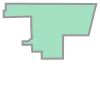

In [3]:
# Define map area
map_area = gpd.read_file(CONFIG[CONFIG_MAP_AREA_PATH]).to_crs(GEODESIC_CRS).loc[0,"geometry"]
map_area

In [6]:
# Instantiate data objects
gtfs_instance = GTFSDataObject(
    CONFIG[CONFIG_GTFS_CACHE_FOLDER],
    CONFIG[CONFIG_GTFS_TRANSITLAND_URL],
    dt.timedelta(days=90),
    dt.time(hour=10), #TODO: need to handle tz
    dt.time(hour=15),
    min_headway=9000,
    api_key_path=CONFIG[CONFIG_GTFS_TRANSITLAND_KEY_PATH],
    gtfs_override_feeds_path=CONFIG[CONFIG_GTFS_OVERRIDE_SHEET]
)
fta_instance = FTAFacilityInventoryDataObject(
    CONFIG[CONFIG_FTA_FACILITY_INVENTORY_PATH],
    CONFIG[CONFIG_TIGER_STATES_PATH],
    CONFIG[CONFIG_OSM_CACHE_FOLDER]
)
citybikes_instance = CityBikesDataObject(CONFIG[CONFIG_CITYBIKES_URL])
afdc_instance = AFDCApiDataObject(CONFIG[CONFIG_AFDC_URL], CONFIG[CONFIG_AFDC_API_KEY],CONFIG[CONFIG_MAP_AREA_PROJECTED_CRS])
osm_bike_parking_instance = OSMBikeParkingDataObject(CONFIG[CONFIG_OSM_CACHE_FOLDER], {"amenity": ["bicycle_parking"]})
base_layer_instance = BaseLayer(
    [
        CensusModeshare(),
        CensusCarlessness(),
        CensusPopulation(),
        BaseLayerSmartLocation(CONFIG[CONFIG_SMART_LOCATION_PATH],CONFIG[CONFIG_MAP_AREA_PROJECTED_CRS]),
        BaseLayerEjscreen(CONFIG[CONFIG_EPA_EJSCREEN_PATH]),
    ],
    "rawData/tl_2023_us_county/tl_2023_us_county.shp",
    CONFIG[CONFIG_MAP_AREA_PROJECTED_CRS],
    ColorMaps.EJSCREEN_ONLY_COLOR_MAP_ID
)
bike_instance = OSMBikeStreetsDataObject(
    CONFIG[CONFIG_OSM_CACHE_FOLDER],
    reference=gtfs_instance,
    local_crs=CONFIG[CONFIG_MAP_AREA_PROJECTED_CRS]
)

all_objects = {
    "GTFS": gtfs_instance,
    "BIKE": bike_instance,
    "FTA": fta_instance,
    "CITYBIKES": citybikes_instance,
    "AFDC": afdc_instance,
    "OSM BIKE PARKING": osm_bike_parking_instance,
    "BASE": base_layer_instance,
}
objects_load_order = (
    "BASE",
    "BIKE",
    "GTFS",
    "FTA",
    "AFDC",
    "OSM BIKE PARKING",
    "CITYBIKES"
)
objects_must_await = (
    "GTFS"
)
await gtfs_instance.load_data(map_area, GEODESIC_CRS)

INFO: Transitland URL: https://transit.land/api/v2/rest/feeds.json?bbox=-88.263641,41.469705,-87.111162,42.154292&limit=100&license_create_derived_product=exclude_no&license_redistribution_allowed=exclude_no&apikey=iMGHYCuvlmhChyTvB9gmQuDonmXnj91W
INFO: Processing f-dp3-cta
INFO: Processing f-dp3-pace
INFO: Processing f-dp3-metra
INFO: Processing f-9-amtrak~amtrakcalifornia~amtrakcharteredvehicle
INFO: Processing f-d-groometransportation~us
INFO: Processing f-dp-945963
INFO: Processing f-valpotransit~chi~us
INFO: Processing f-northern~indiana~commuter~transportation~district
INFO: Processing f-chicagowatertaxi~il~us
INFO: Processing f-gary~public~transportation~in~us
INFO: Processing f-university~of~chicago
INFO: Processing f-9-flixbus
INFO: Processing f-megabus~us
INFO: Processing f-jefferson~mn~us
PRINTING ALL PROCESSED AGENCY IDS: 


In [ ]:
# Load data objects
for name, object in all_objects.items():
    print(name)
    if not object.get_is_loaded():
        if name in objects_must_await:
            await object.load_data(map_area, GEODESIC_CRS)
        else:
            object.load_data(map_area, GEODESIC_CRS)

GTFS
BIKE
FTA
Processing 451 S Buchanan , Edwardsville , IL, US, 62025
INFO: Successfully geocoded 451 S Buchanan , Edwardsville , IL, US, 62025
Processing 3717 S State Rte 157, Glen Carbon, IL, US, 62034
WARN: 3717 S State Rte 157, Glen Carbon, IL, US, 62034 could not be geocoded
Processing 12291 Hwy 40, Highland, IL, US, 62249
WARN: 12291 Hwy 40, Highland, IL, US, 62249 could not be geocoded
Processing 3127 W 20th, Granite City, IL, US, 62040
INFO: Successfully geocoded 3127 W 20th, Granite City, IL, US, 62040
Processing 124 Hillsboro, Edwardsville, IL, US, 62025
INFO: Successfully geocoded 124 Hillsboro, Edwardsville, IL, US, 62025
Processing 1327 19th, Granite City, IL, US, 62040
WARN: 1327 19th, Granite City, IL, US, 62040 could not be geocoded
Processing 527 Lewis and Clark Blvd, East Alton, IL, US, 62024
INFO: Successfully geocoded 527 Lewis and Clark Blvd, East Alton, IL, US, 62024
Processing 10670 Hwy 40, St. Jacob , IL, US, 62281
INFO: Successfully geocoded 10670 Hwy 40, St. 

/Users/jonah-sumc/Documents/sumc_fta_mobility_hub_project/MobilityHubDataObjects/FTAFacilityInventoryDataObject.py:202: UserWarning: The indices of the two GeoSeries are different.
  gdf_all_spaces_with_geometry["distance_to_point"] = gdf_all_spaces_with_geometry.geometry.distance(all_points_projected)
/Users/jonah-sumc/Documents/sumc_fta_mobility_hub_project/MobilityHubDataObjects/CityBikesDataObject.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_citybikes_feeds_us["latitude"] = df_citybikes_feeds_us["location"].map(lambda x: x["latitude"]).copy()
/Users/jonah-sumc/Documents/sumc_fta_mobility_hub_project/MobilityHubDataObjects/CityBikesDataObject.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [ ]:
# Main Map
display_map = folium.Map(
    location=(map_area.centroid.y, map_area.centroid.x),
    tiles="Cartodb Positron",
    zoom_start=10,
    prefer_canvas=True
)
for object in objects_load_order:
    print(object)
    if len(all_objects[object].gdf) > 0: #TODO: quick fix, add "has_entries" method to each data object instead
        all_objects[object].get_folium_plot().add_to(display_map)
#all_objects["GTFS"].get_folium_plot().add_to(display_map)
display_map

In [ ]:
bike_instance.gdf

In [ ]:
display_map.save("test.html")